# Large Missed-Tumor Pipeline Inspection

This notebook traces volumes **302, 305, 308 and 309**, where all three models completely missed a large tumor. It reuses the saved Spatial GMM + NDI parameters and does not retrain or modify any model.

The raw tumor posterior is the tuned Spatial GMM output before NDI. The later panels show where the tumor disappears in the shared image-processing pipeline.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from IPython.display import display

from config import PROJECT_ROOT
from evaluation.evaluate_single_slice import eval_vol

%matplotlib inline

dataset director:  /truenas/home/ratzabiy/MRI_2026_datasets/Brats/BraTS2020_training_data/content/data


In [2]:
PARAMETER_PATH = Path(PROJECT_ROOT) / "saved_parameters" / "spatial_gmm_ndi_fusion_best_params.npz"
FIGURES_DIR = Path(PROJECT_ROOT) / "output" / "required_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
LARGE_MISSED_VOLUMES = [301, 302, 305, 309]
PARAMETER_NAMES = [
    "lambda_val", "tumor_prior_scale", "min_pixels_per_blob",
    "binarization_factor", "blob_class_threshold", "large_contour_min_area",
    "top_posterior_mean_threshold", "high_posterior_fraction_threshold",
    "entropy_thresh", "posterior_min", "max_expansion_diameter", "ndi_strength",
    "ndi_percentile", "ndi_posterior_gate",
]

if not PARAMETER_PATH.exists():
    raise FileNotFoundError("Run main.ipynb first to create the tuned NDI parameter file.")

with np.load(PARAMETER_PATH) as saved:
    ndi_params = {name: saved[name].item() for name in PARAMETER_NAMES}

TRACE_SPEC = {"model_name": "spatial_gmm_ndi", "symmetric": True, **ndi_params}
display(pd.DataFrame(ndi_params.items(), columns=["Parameter", "Value"]))

,Parameter,Value
0,lambda_val,0.160000
1,tumor_prior_scale,0.561916
2,min_pixels_per_blob,16.000000
3,binarization_factor,0.860000
4,blob_class_threshold,0.270000
5,large_contour_min_area,1800.000000
6,top_posterior_mean_threshold,0.300000
7,high_posterior_fraction_threshold,0.150000
8,entropy_thresh,0.320000
9,posterior_min,0.130000


In [3]:
def normalize_for_display(image, brain_mask):
    low, high = np.percentile(image[brain_mask], [1, 99])
    return np.clip((image - low) / max(high - low, 1e-8), 0, 1)

def contour_overlap_count(contours, ground_truth):
    return sum(np.any(contours[:, :, index] & ground_truth) for index in range(contours.shape[-1]))

def contour_union(contours, shape):
    return np.any(contours, axis=-1) if contours.shape[-1] else np.zeros(shape, dtype=bool)

def first_failed_stage(details):
    ground_truth = details["ground_truth"]
    if contour_overlap_count(details["blob_array"], ground_truth) == 0:
        return "Posterior / contour detection"
    if contour_overlap_count(details["classified_blobs"], ground_truth) == 0:
        return "Contour classification"
    if details["intersection"] == 0:
        return "Final expansion"
    return "Detected"

def error_overlay(ground_truth, prediction):
    overlay = np.zeros((*ground_truth.shape, 4), dtype=float)
    overlay[ground_truth & prediction] = (0.15, 0.90, 0.25, 0.75)
    overlay[~ground_truth & prediction] = (1.00, 0.20, 0.10, 0.75)
    overlay[ground_truth & ~prediction] = (0.10, 0.45, 1.00, 0.85)
    return overlay

def show_stage_map(axis, values, brain_mask, ground_truth, cmap, vmax=None):
    axis.imshow(np.where(brain_mask, values, np.nan), cmap=cmap, vmin=0, vmax=vmax)
    axis.contour(ground_truth, levels=[0.5], colors="yellow", linewidths=0.8)
    axis.axis("off")

In [4]:
pipeline_traces = {
    volume: eval_vol(volume, return_details=True, **TRACE_SPEC)
    for volume in LARGE_MISSED_VOLUMES
}

trace_table = pd.DataFrame([
    {
        "Volume": volume,
        "GT pixels": details["gt_size"],
        "Raw posterior mean in GT": details["raw_tumor_posterior"][details["ground_truth"]].mean(),
        "Raw posterior max in GT": details["raw_tumor_posterior"][details["ground_truth"]].max(),
        "NDI mean in GT": details["ndi_score"][details["ground_truth"]].mean(),
        "Detected contours": details["blob_array"].shape[-1],
        "Detected overlapping GT": contour_overlap_count(details["blob_array"], details["ground_truth"]),
        "Classified contours": details["classified_blobs"].shape[-1],
        "Classified overlapping GT": contour_overlap_count(details["classified_blobs"], details["ground_truth"]),
        "Final predicted pixels": details["pred_size"],
        "First failed stage": first_failed_stage(details),
    }
    for volume, details in pipeline_traces.items()
])
display(trace_table.round(4))

,Volume,GT pixels,Raw posterior mean in GT,Raw posterior max in GT,NDI mean in GT,Detected contours,Detected overlapping GT,Classified contours,Classified overlapping GT,Final predicted pixels,First failed stage
0,301,2307,0.1977,0.8133,0.0042,21,10,2,2,2041,Detected
1,302,1694,0.0739,0.7105,0.0000,14,4,0,0,0,Contour classification
2,305,1479,0.1059,0.8714,0.0164,12,7,0,0,0,Contour classification
3,309,1837,0.1277,0.7384,0.0009,13,9,0,0,0,Contour classification


## Stage-by-stage visualization

The yellow outline is the ground truth. Detected contours are orange and contours classified as tumor are green. In the final panel: green = true positive, red = false positive, blue = false negative.

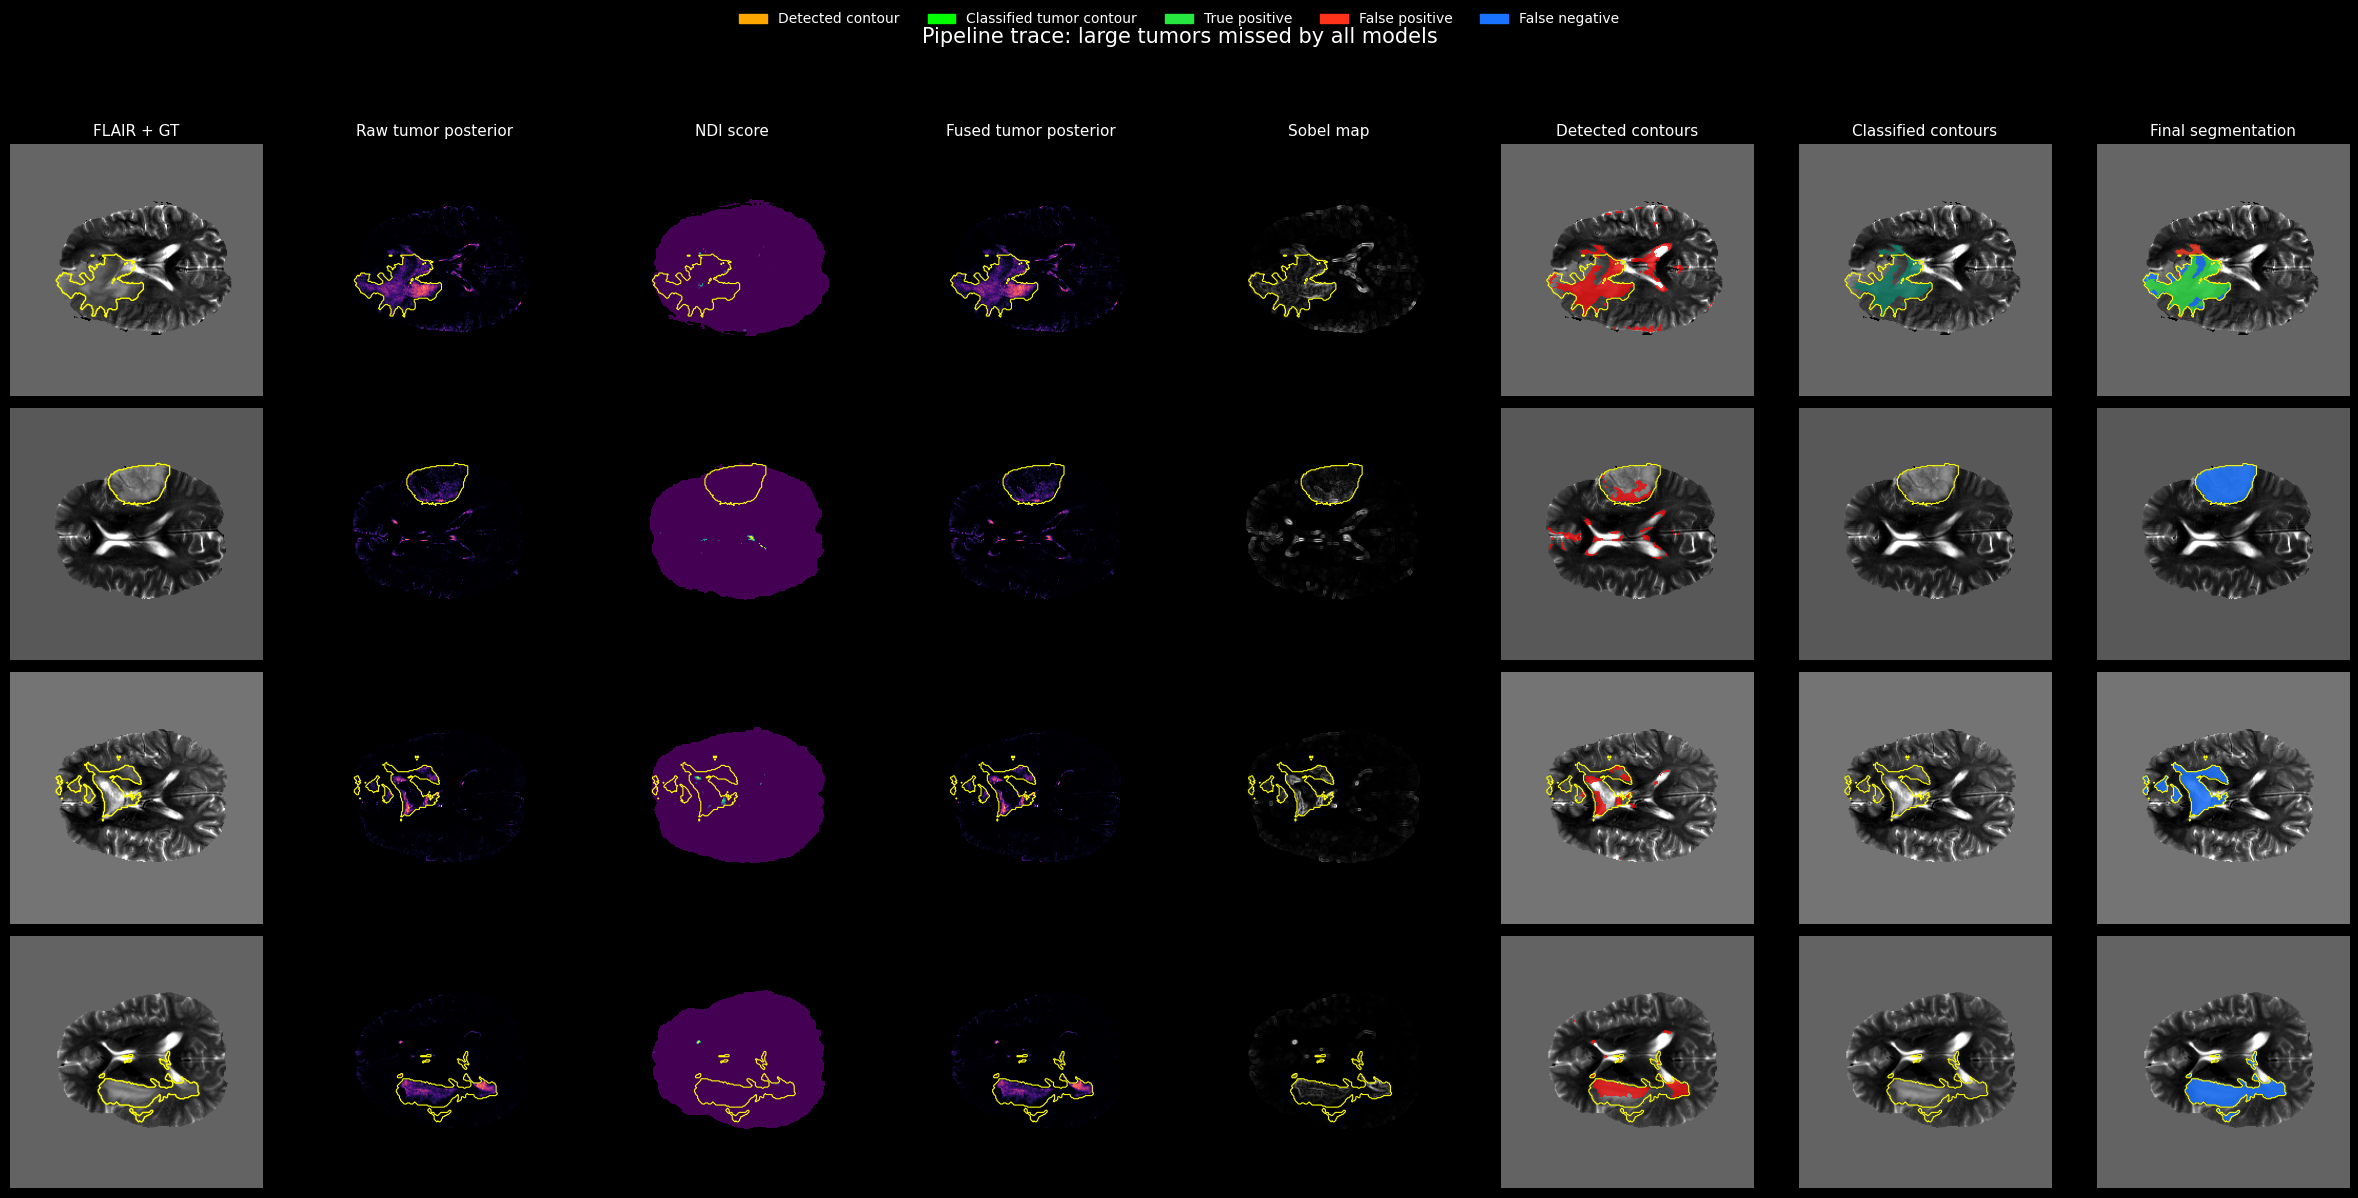

In [5]:
stage_titles = [
    "FLAIR + GT", "Raw tumor posterior", "NDI score",
    "Fused tumor posterior", "Sobel map", "Detected contours",
    "Classified contours", "Final segmentation",
]
fig, axes = plt.subplots(len(LARGE_MISSED_VOLUMES), len(stage_titles), figsize=(24, 12), squeeze=False)

for row, volume in enumerate(LARGE_MISSED_VOLUMES):
    details = pipeline_traces[volume]
    ground_truth = details["ground_truth"]
    brain_mask = details["brain_mask"]
    flair = normalize_for_display(details["image"][:, :, 3], brain_mask)
    fused_posterior = np.sum(details["posteriors"][:, :, -3:], axis=-1)
    detected = contour_union(details["blob_array"], ground_truth.shape)
    classified = contour_union(details["classified_blobs"], ground_truth.shape)

    axes[row, 0].imshow(flair, cmap="gray")
    axes[row, 0].contour(ground_truth, levels=[0.5], colors="yellow", linewidths=1)
    axes[row, 0].set_ylabel(f"Volume {volume}", fontsize=11)
    axes[row, 0].axis("off")
    show_stage_map(axes[row, 1], details["raw_tumor_posterior"], brain_mask, ground_truth, "magma", vmax=1)
    show_stage_map(axes[row, 2], details["ndi_score"], brain_mask, ground_truth, "viridis", vmax=1)
    show_stage_map(axes[row, 3], fused_posterior, brain_mask, ground_truth, "magma", vmax=1)
    show_stage_map(axes[row, 4], details["sobel_map"], brain_mask, ground_truth, "gray")

    for column, mask, cmap in [(5, detected, "autumn"), (6, classified, "summer")]:
        axes[row, column].imshow(flair, cmap="gray")
        axes[row, column].imshow(np.ma.masked_where(~mask, mask), cmap=cmap, alpha=0.7)
        axes[row, column].contour(ground_truth, levels=[0.5], colors="yellow", linewidths=0.8)
        axes[row, column].axis("off")

    axes[row, 7].imshow(flair, cmap="gray")
    axes[row, 7].imshow(error_overlay(ground_truth, details["prediction"]))
    axes[row, 7].contour(ground_truth, levels=[0.5], colors="yellow", linewidths=0.8)
    axes[row, 7].axis("off")

for column, title in enumerate(stage_titles):
    axes[0, column].set_title(title, fontsize=11)

legend = [
    Patch(color="orange", label="Detected contour"),
    Patch(color="lime", label="Classified tumor contour"),
    Patch(color=(0.15, 0.90, 0.25), label="True positive"),
    Patch(color=(1.00, 0.20, 0.10), label="False positive"),
    Patch(color=(0.10, 0.45, 1.00), label="False negative"),
]
fig.legend(handles=legend, loc="upper center", ncol=5, frameon=False)
fig.suptitle("Pipeline trace: large tumors missed by all models", fontsize=15, y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(FIGURES_DIR / "large_missed_tumor_pipeline_trace.png", dpi=220, bbox_inches="tight")
plt.show()

## How to interpret the result

- Weak raw posterior inside the yellow outline indicates a GMM/statistical-model failure.
- Strong raw or fused posterior but zero overlapping detected contours indicates a Sobel/contour-detection failure.
- An overlapping detected contour followed by zero overlapping classified contours indicates a contour-classification failure.
- An overlapping classified contour followed by no final overlap indicates a final expansion failure.

## Per-contour classification diagnostics

This table inspects every detected contour using the **fused tumor posterior** that is passed to the contour classifier.

- **Current weighted-mean score** is the classifier's exact entropy-weighted tumor score; the contour is accepted when this is at least `blob_class_threshold`.
- **Top-20% posterior mean** averages the highest 20% of tumor-posterior pixels inside the contour.
- **High-posterior pixel fraction** is the fraction of contour pixels whose tumor posterior is at least `blob_class_threshold`.
- **Overlaps GT** identifies which detected contours touch the missed tumor; it is diagnostic only and is not used by the model.

In [6]:
from image_processing.contour_classification import entropy_weighted_mean

def contour_diagnostic_rows(volume, details):
    rows = []
    tumor_posterior = np.sum(details["posteriors"][:, :, -3:], axis=-1)
    threshold = ndi_params["blob_class_threshold"]
    for contour_index in range(details["blob_array"].shape[-1]):
        contour = details["blob_array"][:, :, contour_index]
        pixel_posteriors = tumor_posterior[contour]
        top_count = max(1, int(np.ceil(0.2 * pixel_posteriors.size)))
        _, normalized_scores = entropy_weighted_mean(
            contour, details["posteriors"], details["entropy_map"]
        )
        rows.append({
            "Volume": volume,
            "Contour": contour_index,
            "Current weighted-mean score": np.sum(normalized_scores[-3:]),
            "Top-20% posterior mean": np.partition(pixel_posteriors, -top_count)[-top_count:].mean(),
            "High-posterior pixel fraction": np.mean(pixel_posteriors >= threshold),
            "Contour area": int(contour.sum()),
            "Overlaps GT": bool(np.any(contour & details["ground_truth"])),
            "Accepted": bool(details["is_tumor_list"][contour_index]),
        })
    return rows

contour_diagnostics = pd.DataFrame([
    row
    for volume, details in pipeline_traces.items()
    for row in contour_diagnostic_rows(volume, details)
]).sort_values(["Volume", "Overlaps GT", "Current weighted-mean score"], ascending=[True, False, False])

print(f"Contour acceptance threshold: {ndi_params['blob_class_threshold']:.4f}")
display(contour_diagnostics.round(4))

Contour acceptance threshold: 0.2700


,Volume,Contour,Current weighted-mean score,Top-20% posterior mean,High-posterior pixel fraction,Contour area,Overlaps GT,Accepted
8,301,8,0.2802,0.3390,0.5714,21,True,True
11,301,11,0.2344,0.2948,0.1667,18,True,False
13,301,13,0.2313,0.3192,0.2308,26,True,False
10,301,10,0.2160,0.2846,0.1351,37,True,False
7,301,7,0.2116,0.2732,0.0833,24,True,False
12,301,12,0.2029,0.2686,0.0833,48,True,False
5,301,5,0.1838,0.4637,0.2952,1897,True,True
9,301,9,0.1733,0.2306,0.0172,58,True,False
6,301,6,0.1222,0.1861,0.0000,18,True,False
3,301,3,0.1139,0.2949,0.1045,67,True,False
